# Step 02b. Where the 28 interferon response genes land

Reads `ifn_panel.csv` (step 01b) and `wgcna_A.rds` (step 02). Writes `ifn_A.rds` to
`data/run_artifacts/` and two figures to `figures/`.

**Objective.** Name the interferon-associated protein module in the cohort A network fit, once, so
that steps 05, 08 and 09 read the answer rather than each deriving it again.

**Why the module must never be named by its colour.** WGCNA assigns colours by module rank within a
single fit. `skyblue` in one fit and `skyblue` in another are unrelated. This module has been
`royalblue`, `darkorange`, `blue`, `ivory` and now `skyblue` across runs of this same pipeline: the same proteins,
never the same name. So the name has to be looked up every time, from the data.

**Two methods, both cited, run side by side.**

1. **A description**, which is the method used in `endotypes-transcriptomics`, notebook
   `05c_GSE65391_RNA_array_interferon_genes`: the interferon module is the module that holds the most
   of the 28 interferon response genes. No test is performed and none is claimed. What makes it
   defensible is the control: the 11 NF-kB-only genes of de Jesus AA et al. *J Clin Invest*
   2020;130:1669-1682 (Methods Step 2, Supplemental Figure 5) have no STAT1, STAT2 or TYK1 binding
   site, so they should land elsewhere. If they do not, the description means nothing.
2. **A test**, which is the method used by the paper that published these data. Leung GHD et al.
   *Mapping the plasma proteomic architecture of systemic lupus erythematosus*, JCI Insight 2026
   (doi:10.1172/jci.insight.206938), Methods: "Over-representation tests were used to identify
   enriched pathways in WGCNA protein modules ... implemented using the enrichPathway function from
   the ReactomePA R package". The test is hypergeometric, Benjamini-Hochberg corrected, against the
   Reactome database, with pathway sets restricted to 10-500 proteins and a background of the Entrez
   IDs actually measured.
   - Yu G, He QY. ReactomePA: an R/Bioconductor package for reactome pathway analysis and
     visualization. *Mol Biosyst* 2016;12:477-479, doi:10.1039/C5MB00663E.
   - Benjamini Y, Hochberg Y. Controlling the false discovery rate. *J R Stat Soc B* 1995;57:289-300.

**Agreement between the two is the result. Disagreement is also a result, and is reported as one.**

**Module membership (kME)** is each protein's Pearson correlation with a module eigenprotein
(Horvath S, Dong J. Geometric interpretation of gene coexpression network analysis. *PLoS Comput
Biol* 2008;4:e1000117). It is a description of position within a module, not a test.

## Load the panel and the fit

In [1]:
source("../src/paths.R")
suppressMessages({library(ReactomePA); library(org.Hs.eg.db)})
COHORT <- "A"
p <- read.csv(art("ifn_panel.csv"), stringsAsFactors = FALSE)
w <- readRDS(art("wgcna_%s.rds", COHORT))
X <- w$X; mods <- w$mods; ME <- w$ME
p$in_network <- p$column %in% colnames(X)
p$module     <- ifelse(p$in_network, mods[match(p$column, colnames(X))], NA_character_)
c(patients = nrow(X), probes = ncol(X), proteins = n_proteins(colnames(X)),
  modules = length(setdiff(unique(mods), "grey")), unassigned_grey = sum(mods == "grey"),
  curated_reagents_in_network = sum(p$in_network))

patients                      probes 
                         87                        7288 
                   proteins                     modules 
                       6399                          33 
            unassigned_grey curated_reagents_in_network 
                       1107                          25

**Explanation**
- `library(ReactomePA)` provides `enrichPathway()`; `library(org.Hs.eg.db)` is the Entrez ID map it
  needs to print gene symbols back out.
- `read.csv(art("ifn_panel.csv"))` is the panel step 01b wrote: one row per curated gene per SOMAmer,
  with `column` holding the name the cohort matrix carries and `NA` for a gene the assay lacks.
- `readRDS(art("wgcna_%s.rds", COHORT))` is the fit step 02 saved. `X` is patients by reagents,
  `mods` is one module colour per column of `X`, `ME` holds the module eigenproteins.
- `p$column %in% colnames(X)` is TRUE for reagents that are in this fit. `match()` then finds each
  one's position in `colnames(X)` so `mods[...]` gives its module. Reagents not in the fit get `NA`
  rather than being dropped, so the count stays auditable.
- `grey` is not a module. It is WGCNA's label for reagents that joined no module, so it is counted
  separately everywhere below.
- `n_proteins()` counts distinct genes behind the reagents, because a SomaScan column is a SOMAmer
  and several can target one protein.

## Which module holds the 28 interferon response genes

In [2]:
tab <- sort(table(p$module[p$set == "IRG-28"]), decreasing = TRUE)
cat("the 12 IRG-28 reagents by module:\n"); print(tab)
named      <- tab[names(tab) != "grey"]
ifn_module <- names(named)[1]
n_curated  <- sum(p$set == "IRG-28" & p$in_network)
cat(sprintf("\ninterferon module  : %s, holding %d of the %d IRG-28 reagents\n",
            ifn_module, named[[1]], n_curated))
cat(sprintf("runner-up          : %s, holding %d\n",
            names(named)[2], named[[2]]))
cat(sprintf("in grey, unassigned: %d\n",
            if ("grey" %in% names(tab)) tab[["grey"]] else 0L))

the 12 IRG-28 reagents by module:



  skyblue      blue turquoise     brown      grey 
        6         2         2         1         1 



interferon module  : skyblue, holding 6 of the 12 IRG-28 reagents


runner-up          : blue, holding 2


in grey, unassigned: 1


**Explanation**
- `table()` counts how many of the 12 IRG-28 reagents fall in each module;
  `sort(..., decreasing = TRUE)` puts the largest count first.
- `tab[names(tab) != "grey"]` drops the unassigned pool before taking the largest. This is not a
  threshold and not a filter of results: `grey` is the set of reagents WGCNA placed in no module, so
  it cannot be the answer to "which module". Its count is printed on its own line so the reader can
  see how much of the curated set went unassigned.
- `names(named)[1]` is the interferon module, by the definition stated at the top: the module holding
  the most of the 28. The runner-up is printed so the margin is visible rather than implied.

## The control: the 11 NF-kB-only genes

In [3]:
ctrl <- sort(table(p$module[p$set == "NF-kB-11"]), decreasing = TRUE)
cat("the 13 NF-kB-only reagents by module:\n"); print(ctrl)
cat(sprintf("\nin the interferon module (%s): %d of %d\n", ifn_module,
            sum(p$module == ifn_module & p$set == "NF-kB-11", na.rm = TRUE),
            sum(p$in_network & p$set == "NF-kB-11")))

the 13 NF-kB-only reagents by module:



     grey turquoise       red      blue     green    yellow 
        4         4         2         1         1         1 



in the interferon module (skyblue): 0 of 13


**Explanation**
- The same count, run on the control list. These 11 genes are NF-kB targets with no STAT1, STAT2 or
  TYK1 binding site (de Jesus 2020), so they are immune genes that are not interferon-stimulated.
  They are the hard null, not a random one.
- If the interferon module held several of them, the description above would be describing "immune
  activation" rather than "interferon", and would have to be withdrawn.

## Module membership (kME) of each protein

In [4]:
p$kME_ifn <- NA_real_
p$kME_ifn[p$in_network] <- round(
  cor(X[, p$column[p$in_network]], ME[[paste0("ME", ifn_module)]])[, 1], 2)
print(p[p$in_network, c("set", "gene", "SeqId", "column", "module", "kME_ifn")], row.names = FALSE)

      set    gene        SeqId            column    module kME_ifn
   IRG-28  CXCL10  seq.4141.79            CXCL10   skyblue    0.69
   IRG-28    GBP1 seq.15326.64              GBP1   skyblue    0.75
   IRG-28   HERC5  seq.12934.1             HERC5     brown    0.03
   IRG-28   IFIT2   seq.9853.3             IFIT2      grey    0.29
   IRG-28   IFIT3 seq.13642.90             IFIT3   skyblue    0.90
   IRG-28   ISG15  seq.14148.2 ISG15_seq.14148.2   skyblue    0.92
   IRG-28   ISG15  seq.14151.4 ISG15_seq.14151.4   skyblue    0.91
   IRG-28     MX1 seq.17460.51               MX1   skyblue    0.92
   IRG-28    OAS1 seq.10361.25              OAS1      blue    0.40
   IRG-28    OASL  seq.25941.4              OASL turquoise    0.17
   IRG-28    RTP4 seq.18315.38              RTP4 turquoise    0.36
   IRG-28 SIGLEC1  seq.4464.10           SIGLEC1      blue    0.43
 NF-kB-11    EBI3 seq.10851.77              EBI3      grey   -0.14
 NF-kB-11    GZMB seq.14041.13 GZMB_seq.14041.13       red    

**Explanation**
- `NA_real_` fills the column with missing numbers first, so reagents outside the fit stay missing
  rather than silently becoming zero.
- `cor(X[, cols], ME[[paste0("ME", ifn_module)]])` correlates each reagent with the interferon module
  eigenprotein over the patients of this cohort. `paste0("ME", ...)` builds the eigenprotein's column
  name, for example `MEskyblue`. `[, 1]` takes the single column the result has.
- This is Pearson, and deliberately so: both quantities are continuous log2 abundances or a linear
  combination of them, and kME is defined as the Pearson correlation with the eigengene
  (Horvath and Dong 2008).
- No p value is computed. kME says where a protein sits inside a module; it does not test anything.

## Summary by gene list

In [5]:
summ <- do.call(rbind, lapply(split(p, p$set), function(d) data.frame(
  set = d$set[1], genes = length(unique(d$gene)),
  on_menu = length(unique(d$gene[d$on_menu])), reagents = sum(d$on_menu),
  in_network = sum(d$in_network),
  in_ifn_module  = sum(d$module == ifn_module, na.rm = TRUE),
  median_kME_ifn = median(d$kME_ifn, na.rm = TRUE),
  min_kME = min(d$kME_ifn, na.rm = TRUE), max_kME = max(d$kME_ifn, na.rm = TRUE))))
print(summ, row.names = FALSE)

      set genes on_menu reagents in_network in_ifn_module median_kME_ifn
   IRG-28    28      11       12         12             6           0.56
 NF-kB-11    11       8       13         13             0           0.05
 min_kME max_kME
    0.03    0.92
   -0.18    0.25


**Explanation**
- `split(p, p$set)` divides the table into the interferon response genes and the controls, one
  summary row each.
- `sum()` over TRUE and FALSE counts the TRUE values; `na.rm = TRUE` skips the reagents that are not
  in the fit.
- The two rows are the comparison the control exists to make: how many of each list are in the
  interferon module, and how their kME distributions differ.

## Over-representation of Reactome pathways, the method used in the source paper

In [6]:
fm  <- read.delim(raw("feature_metadata.txt"), check.names = FALSE)
ent <- setNames(trimws(as.character(fm$EntrezGeneID)), fm$GeneSymbol)
ent[!nzchar(ent)] <- NA
universe <- unique(na.omit(ent[colnames(X)]))
IFN_PATHWAYS <- c("R-HSA-913531",   # Interferon Signaling
                  "R-HSA-909733",   # Interferon alpha/beta signaling
                  "R-HSA-877300")   # Interferon gamma signaling
cat("background Entrez IDs:", length(universe), " (the paper reports 6,363)\n")
cat("modules tested       :", length(setdiff(unique(mods), "grey")), "\n")

background Entrez IDs: 6396  (the paper reports 6,363)


modules tested       : 33 


**Explanation**
- `setNames(fm$EntrezGeneID, fm$GeneSymbol)` builds the map from a cohort-matrix column name to an
  Entrez gene ID, taken from the study's own reagent table rather than from any external annotation.
  Two of the 7,288 reagents have no Entrez ID and become `NA`.
- `universe` is the background for the test: the distinct Entrez IDs of every reagent in this fit.
  An over-representation test is only interpretable against the set that could have been measured,
  which here is the SomaScan v4.1 menu and not the genome.
- `IFN_PATHWAYS` are the three human Reactome pathways whose names are interferon signalling, taken
  from the Reactome content service. They are named by stable identifier, not by description text,
  because descriptions change between Reactome releases and identifiers do not.
- **Reactome is versioned content.** Which proteins belong to `R-HSA-909733` is a property of the
  `reactome.db` release, printed in the provenance cell at the end of this notebook. The paper used
  ReactomePA v1.42.0; this environment pins R 4.4, whose Bioconductor release carries a later
  ReactomePA, so the versions are recorded rather than matched.

In [7]:
# One test per module, 52 of them. enrichPathway rebuilds its Reactome mapping on
# every call, so this cell takes about 9 minutes -- the single slowest step in the
# pipeline. It is left running rather than cached, because a cached enrichment
# would silently outlive a change to the fit or to reactome.db.
mlist <- setdiff(unique(mods), "grey")
t0   <- Sys.time()
ora <- do.call(rbind, lapply(mlist, function(k) {
  gs <- unique(na.omit(ent[colnames(X)[mods == k]]))
  if (length(gs) < 5) return(NULL)
  d <- as.data.frame(suppressMessages(enrichPathway(
         gene = gs, organism = "human", universe = universe,
         pvalueCutoff = 1, qvalueCutoff = 1, pAdjustMethod = "BH",
         minGSSize = 10, maxGSSize = 500, readable = FALSE)))
  if (!nrow(d)) return(NULL)
  d <- d[order(d$p.adjust), ]
  i <- d[d$ID %in% IFN_PATHWAYS, , drop = FALSE]
  data.frame(module = k, reagents = sum(mods == k), entrez = length(gs),
             top_pathway = substr(d$Description[1], 1, 44),
             top_p_adj   = signif(d$p.adjust[1], 2),
             ifn_pathway = if (nrow(i)) substr(i$Description[1], 1, 32) else NA_character_,
             ifn_p_adj   = if (nrow(i)) signif(i$p.adjust[1], 2)        else NA_real_,
             ifn_hits    = if (nrow(i)) i$Count[1]                      else NA_integer_,
             stringsAsFactors = FALSE)
}))
cat(sprintf("%d modules tested in %.0f s\n", length(mlist),
            as.numeric(difftime(Sys.time(), t0, units = "secs"))))
saveRDS(ora, art("ifn_reactome_%s.rds", COHORT))
ora <- ora[order(ora$ifn_p_adj, na.last = TRUE), ]
print(head(ora, 10), row.names = FALSE)

33 modules tested in 348 s


      module reagents entrez                                  top_pathway
     skyblue       27     23                         Interferon Signaling
      yellow      305    295                Rab regulation of trafficking
   steelblue       22     22 Cytochrome P450 - arranged by substrate type
 greenyellow       41     39                     Metabolism of porphyrins
   royalblue       34     27 Regulation of HSF1-mediated heat shock respo
  lightgreen       36     35 Regulation of MITF-M-dependent genes involve
  darkorange       29     29               Interleukin-1 family signaling
   lightcyan       37     37                       Viral mRNA Translation
      purple       48     48                         Attachment and Entry
      salmon       39     38                  Maturation of spike protein
 top_p_adj                     ifn_pathway ifn_p_adj ifn_hits
   3.2e-04            Interferon Signaling   0.00032        6
   1.2e-03            Interferon Signaling   0.04200       15


**Explanation**
- `mlist` is every module except `grey`. Each is tested separately, which is what the paper did:
  one over-representation test per module, not one test of the whole network.
- `gs` is the module's distinct Entrez IDs. `unique()` matters here: ISG15 has two reagents and one
  Entrez ID, and counting it twice would inflate the module's apparent size in the test.
- `if (length(gs) < 5) return(NULL)` skips modules with fewer than 5 distinct genes. A
  hypergeometric test on 4 genes against pathway sets of 10 to 500 cannot reach significance, so this
  drops nothing that could have been found; it is a statement about the test's resolution.
- `enrichPathway()` arguments, all of them the paper's:
  - `gene`, `universe`: the module and the background.
  - `minGSSize = 10`, `maxGSSize = 500`: the paper's restriction, "to exclude very small sets
    vulnerable to noise and large sets representing broad and non-specific processes".
  - `pAdjustMethod = "BH"`: Benjamini-Hochberg across the pathways tested for this module.
  - `pvalueCutoff = 1`, `qvalueCutoff = 1`: return every pathway tested rather than only the
    significant ones, so the table below shows the adjusted p values instead of a filtered list. The
    correction is unaffected by the cutoff.
  - `readable = FALSE`: keep Entrez IDs. Mapping them back to symbols costs about a fifth of the
    runtime and nothing below uses the symbols, only each pathway's description and hit count.
- `d[d$ID %in% IFN_PATHWAYS, ]` picks the interferon pathways out of that module's results by stable
  identifier. `top_pathway` is the module's single most enriched pathway whatever it is, so a module
  can be seen to be about something else entirely.
- `saveRDS()` keeps the full table; the print shows the ten modules with the smallest adjusted p for
  an interferon pathway.

## Do the description and the test agree

In [8]:
by_test <- ora$module[which.min(ora$ifn_p_adj)]
cat(sprintf("by description (most of the 28)      : %s\n", ifn_module))
cat(sprintf("by over-representation test          : %s  (%s, BH p = %s, %d genes)\n",
            by_test, ora$ifn_pathway[1], format(ora$ifn_p_adj[1]), ora$ifn_hits[1]))
cat(sprintf("\nthe two methods %s\n",
            if (identical(ifn_module, by_test)) "AGREE" else
              "DISAGREE -- this is reported, not resolved here"))
rb <- colnames(X)[mods == ifn_module]
k  <- sort(cor(X[, rb], ME[[paste0("ME", ifn_module)]])[, 1], decreasing = TRUE)
cat(sprintf("\nmodule %s: %s\n", ifn_module, size_str(rb)))
print(round(k, 3))

by description (most of the 28)      : skyblue


by over-representation test          : skyblue  (Interferon Signaling, BH p = 0.00032, 6 genes)



the two methods AGREE



module skyblue: 27 probes (23 proteins)


 ISG15_seq.14148.2                MX1  ISG15_seq.14151.4              IFIT3 
             0.919              0.917              0.906              0.899 
             DDX58            ANKRD45 STAT1_seq.10370.21               C1QC 
             0.893              0.856              0.819              0.761 
              GBP1  LAG3_seq.9950.229               INHA               ZBP1 
             0.755              0.731              0.720              0.719 
            CXCL10   LAG3_seq.5099.14              IFIH1           LGALS3BP 
             0.692              0.677              0.675              0.650 
  FCN3_seq.5462.62              APOL2               NADK              DHX58 
             0.638              0.604              0.579              0.522 
            LILRA3   FCN3_seq.14077.6 SCARF2_seq.8956.96             CRTAC1 
             0.522              0.403             -0.521             -0.532 
              ATRN   FCN1_seq.3613.62   FCN1_seq.22961.7 
            -0.565

**Explanation**
- `which.min(ora$ifn_p_adj)` is the module with the strongest interferon over-representation. `ora`
  was sorted by that column, so row 1 carries its pathway, adjusted p and gene count.
- `identical()` compares the two answers. The notebook prints which it is and does not choose.
- `k` is every reagent in the module ranked by kME, so the hub is the first entry and the module's
  full membership is visible rather than summarised.
- `size_str()` prints "n reagents (m proteins)", because the two counts differ.

## How this compares with the published analysis

In [9]:
cat("published, Leung et al. 2026, discovery set n = 207:\n")
cat("   21 modules, interferon module 'red', 35 proteins, hub ISG15 seq.14148.2\n\n")
cat(sprintf("here, cohort %s, n = %d:\n", COHORT, nrow(X)))
cat(sprintf("   %d modules, interferon module '%s', %s, hub %s at kME %.3f\n",
            length(mlist), ifn_module, size_str(rb), names(k)[1], k[[1]]))
isg <- grep("^ISG15", names(k))
cat(sprintf("\nthe paper's hub reagent ISG15 seq.14148.2 ranks %d here, kME %.3f\n",
            which(names(k) == "ISG15_seq.14148.2"), k[["ISG15_seq.14148.2"]]))
cat("ISG15 reagents in this module, by kME rank:",
    paste(sprintf("%s (%d, %.3f)", names(k)[isg], isg, k[isg]), collapse = "; "), "\n")

published, Leung et al. 2026, discovery set n = 207:


   21 modules, interferon module 'red', 35 proteins, hub ISG15 seq.14148.2



here, cohort A, n = 87:


   33 modules, interferon module 'skyblue', 27 probes (23 proteins), hub ISG15_seq.14148.2 at kME 0.919



the paper's hub reagent ISG15 seq.14148.2 ranks 1 here, kME 0.919


ISG15 reagents in this module, by kME rank: ISG15_seq.14148.2 (1, 0.919); ISG15_seq.14151.4 (3, 0.906) 


**Explanation**
- The comparison is printed rather than asserted in prose, so it is recomputed on every run and
  cannot go stale.
- `which(names(k) == "ISG15_seq.14148.2")` is the rank of the reagent the paper names as its hub.
- `grep("^ISG15", names(k))` finds both ISG15 reagents, since ISG15 is one of the genes this menu
  measures twice.

**This is not a reproduction of the published module, and must not be described as one.** The paper
fits one network on 207 patients and reports 21 modules. This fits one network on 87 and reports far
more, because `minModuleSize` is 5 here, and because a smaller sample gives a noisier correlation
matrix and therefore finer modules. The module count, the colour and the protein count are all
expected to differ. What is comparable is whether the same proteins co-cluster and whether the same
protein is central, and those are the two lines printed above.

**The parameters here are the paper's, exactly.** Its Supplemental Methods, section 1, gives an
unsigned network, soft-thresholding power 6, minimum module size 20 and a merge threshold of 0.25
under a dynamic tree cut. All four are used. What is not matched is the sample: they fit 207 SLE
samples from Batch A alone, and cohort A here is 87 samples, 69 from Batch A and 18 from Batch B, one
third of a three-way split. So a difference in module count is expected; a difference in which
proteins co-cluster is not, and step 20 measures that directly.

## Save

In [10]:
saveRDS(list(cohort = COHORT, module = ifn_module, by_description = ifn_module,
             by_test = by_test, agree = identical(ifn_module, by_test),
             reactome = ora[1, ], panel = p, kME = k,
             reactome_db = as.character(packageVersion("reactome.db")),
             reactomepa  = as.character(packageVersion("ReactomePA"))),
        art("ifn_%s.rds", COHORT))
write.csv(p, art("ifn_panel_%s.csv", COHORT), row.names = FALSE)
cat("wrote", art("ifn_%s.rds", COHORT), "and", art("ifn_panel_%s.csv", COHORT), "\n")
cat("steps 05, 08 and 09 read the module name from this file rather than deriving it again.\n")

wrote /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/endotypes-proteomics/data/run_artifacts/ifn_A.rds and /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/endotypes-proteomics/data/run_artifacts/ifn_panel_A.csv 


steps 05, 08 and 09 read the module name from this file rather than deriving it again.


**Explanation**
- The saved object carries the answer, both routes to it, whether they agreed, the panel with each
  reagent's module and kME, and the two package versions the test depended on. A later notebook that
  reads `$module` therefore also has the evidence behind it in the same file.
- `ifn_panel_A.csv` is the same table as a CSV, for reading outside R.

## Figure: the interferon response genes and the controls

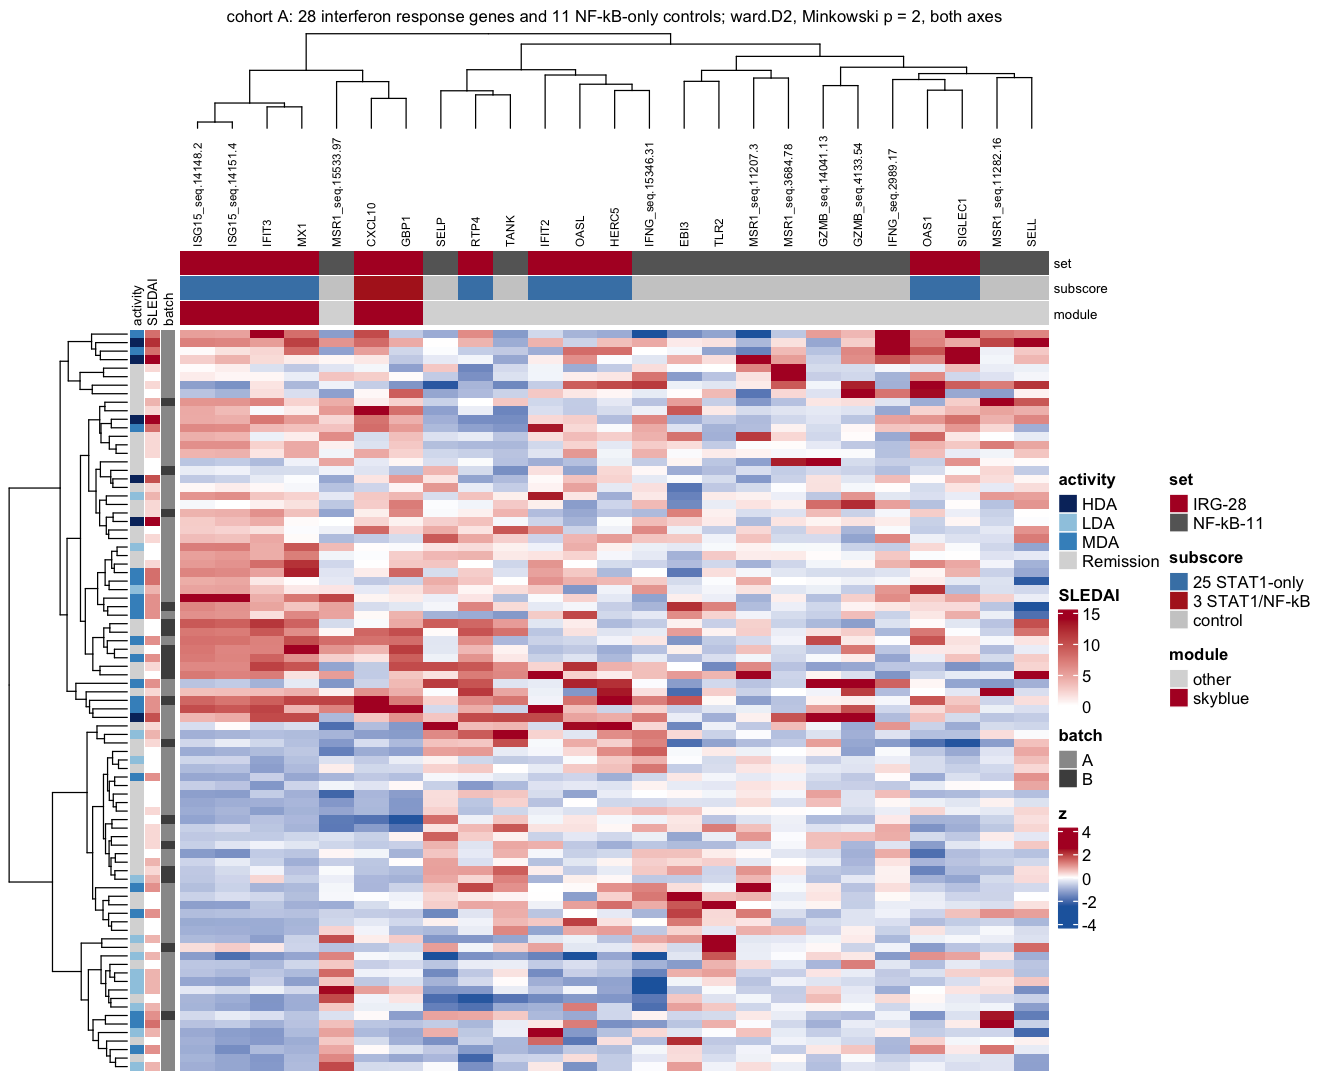

In [11]:
suppressMessages({library(ComplexHeatmap); library(circlize)})
keep <- p$in_network
H  <- scale(X[, p$column[keep], drop = FALSE])
H  <- H[, colSums(is.na(H)) == 0, drop = FALSE]
Hc <- pmin(pmax(H, -2.5), 2.5)
gs <- p[match(colnames(H), p$column), ]
hc_rows <- hclust(dist(H,   method = "minkowski", p = 2), method = "ward.D2")
hc_cols <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
top <- HeatmapAnnotation(
  set = gs$set, subscore = gs$dejesus2020_subscore,
  module = ifelse(gs$module == ifn_module, ifn_module, "other"),
  col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
             subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick",
                          "control" = "grey80"),
             module = setNames(c("#B2182B", "grey85"), c(ifn_module, "other"))),
  # names on the RIGHT: the row annotation is now named at the top, and both sets
  # of labels would otherwise land in the same top-left corner and overlap.
  annotation_name_side = "right", annotation_name_gp = gpar(fontsize = 8))
m    <- w$meta[rownames(H), ]
left <- rowAnnotation(
  activity = m$Disease_activity, SLEDAI = m$SLEDAI_2K, batch = m$Batch, na_col = "grey92",
  annotation_name_side = "top",
  col = list(activity = c(Remission = "grey85", LDA = "#9ecae1", MDA = "#4292c6", HDA = "#08306b"),
             SLEDAI = colorRamp2(c(0, 14), c("white", "#B2182B")),
             batch = c(A = "grey60", B = "grey30")),
  annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))
figure <- function() {
  Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc_rows, cluster_columns = hc_cols,
          row_dend_side = "left", column_dend_side = "top",
          row_dend_width = unit(25, "mm"), column_dend_height = unit(20, "mm"),
          show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 7),
          top_annotation = top, left_annotation = left,
          column_title = sprintf("cohort %s: 28 interferon response genes and 11 NF-kB-only controls; ward.D2, Minkowski p = 2, both axes", COHORT),
          column_title_gp = gpar(fontsize = 10))
}
options(repr.plot.width = 11, repr.plot.height = 9)
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("02b_interferon_heatmap_%s.png", COHORT),
                           width = 11, height = 9, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `library(ComplexHeatmap)` draws heatmaps with dendrograms and annotation strips (Gu Z, Eils R,
  Schlesner M. Complex heatmaps reveal patterns and correlations in multidimensional genomic data.
  *Bioinformatics* 2016;32:2847-2849). `library(circlize)` provides `colorRamp2()`, which maps
  numbers to colours (Gu Z, Gu L, Eils R, Schlesner M, Brors B. circlize implements and enhances
  circular visualization in R. *Bioinformatics* 2014;30:2811-2812).
- `scale(X[, cols])` z-scores each reagent across the patients of this cohort, so the colour shows a
  patient's position relative to the cohort and not the reagent's absolute abundance. Reagents that
  do not vary would give `NaN` and are dropped. `Hc` caps the colours at -2.5 and 2.5 so a few
  extreme patients do not flatten everything else.
- `hc_rows` and `hc_cols` are Ward trees of the patients and of the reagents, `ward.D2` linkage on a
  Minkowski distance with `p = 2`, the same on both axes as everywhere else in this repository.
  `ward.D2` is Ward's criterion applied to the distances themselves rather than their squares
  (Murtagh F, Legendre P. Ward's hierarchical agglomerative clustering method. *J Classif*
  2014;31:274-295). Minkowski with `p = 2` is Euclidean distance, named explicitly so the exponent is
  visible.
- `top` marks each reagent's list, its de Jesus 2020 subscore, and whether it is in the interferon
  module. **The reagent tree and that top strip together are the control:** if the description holds,
  the interferon reagents in the module separate from the NF-kB-only controls.
- `left` shows disease activity, SLEDAI-2K and ComBat batch for each patient, beside the patient
  tree.
- The figure loop draws the figure twice, once inline into this notebook and once into a 300 dpi PNG
  under `figures/`. `draw(out)` is needed because a ComplexHeatmap object only renders when drawn,
  and `inherits()` keeps the loop usable for base-graphics figures too.

## Figure: kME against the interferon module

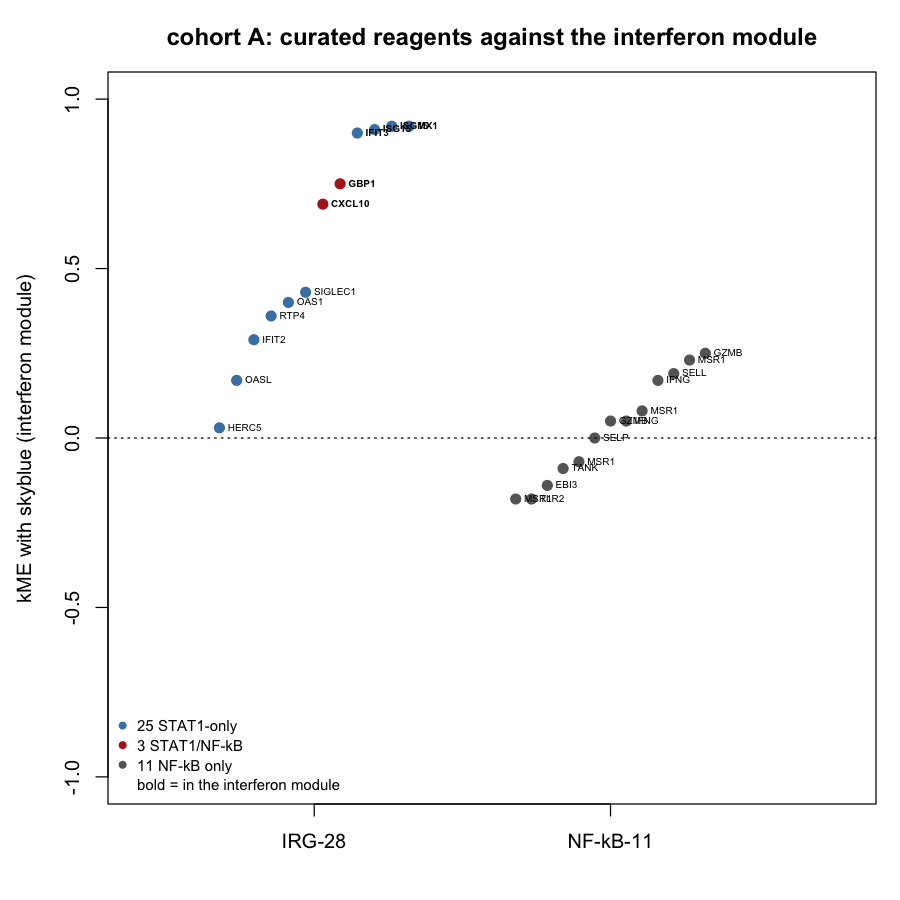

In [12]:
# kME scatter. The reagents are spread across each column BY RANK, so points that
# are close in kME are far apart horizontally and their labels cannot collide. The
# earlier version offset only the three STAT1/NF-kB genes, which left ISG15, MX1 and
# IFIT3 printed on top of each other at the top of the plot.
kme_scatter <- function(d, ifn, COHORT, subtitle = NULL) {
  d <- d[!is.na(d$kME_ifn), ]
  d <- do.call(rbind, lapply(split(d, d$set), function(g) {
    g <- g[order(g$kME_ifn), ]
    base <- if (g$set[1] == "IRG-28") 1 else 2
    g$x <- base + if (nrow(g) > 1) seq(-0.32, 0.32, length.out = nrow(g)) else 0
    g
  }))
  par(mar = c(4, 4.5, if (is.null(subtitle)) 3 else 4.2, 1))
  plot(d$x, d$kME_ifn, xlim = c(0.4, 2.8), ylim = c(-1, 1), xaxt = "n", pch = 19, cex = 1.1,
       col = ifelse(d$set == "NF-kB-11", "grey40",
             ifelse(d$dejesus2020_subscore == "3 STAT1/NF-kB", "firebrick", "steelblue")),
       xlab = "", ylab = paste0("kME with ", ifn, " (interferon module)"),
       main = sprintf("cohort %s: curated reagents against the interferon module", COHORT))
  if (!is.null(subtitle)) mtext(subtitle, side = 3, line = 0.3, cex = 0.72)
  axis(1, at = 1:2, labels = c("IRG-28", "NF-kB-11")); abline(h = 0, lty = 3)
  # a reagent in the module is labelled in bold, so membership reads off the plot
  inmod <- !is.na(d$module) & d$module == ifn
  text(d$x, d$kME_ifn, d$gene, pos = 4, cex = 0.5, offset = 0.35,
       font = ifelse(inmod, 2, 1))
  legend("bottomleft", c("25 STAT1-only", "3 STAT1/NF-kB", "11 NF-kB only",
                         "bold = in the interferon module"),
         pch = c(19, 19, 19, NA), col = c("steelblue", "firebrick", "grey40", NA),
         bty = "n", cex = 0.75)
}
figure <- function() kme_scatter(p[p$in_network, ], ifn_module, COHORT)
options(repr.plot.width = 7.5, repr.plot.height = 7.5)
for (device in c("inline", "png")) {
  if (device == "png") png(fig("02b_interferon_kme_%s.png", COHORT),
                           width = 7.5, height = 7.5, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Explanation**
- One point per reagent in the fit: its kME with the interferon module on the vertical axis, the
  interferon response genes on the left and the controls on the right.
- `d$x` spreads the reagents across each column **by rank**, so two points with similar kME are far
  apart horizontally and their labels cannot collide. The earlier version offset only the three
  STAT1/NF-kB genes, which left ISG15, MX1 and IFIT3 printed on top of one another.
- Colours: blue for the 25 STAT1-only genes, red for CXCL10, GBP1 and SOCS1, grey for the controls.
- `text(..., pos = 4)` labels each point with its gene symbol, in **bold** where that reagent is in
  the interferon module, so membership can be read off the plot rather than inferred from height.
- The figure loop is the same as above; base graphics need no `draw()`.

## Provenance

In [13]:
# Provenance. The rendered notebook is committed, so it records where it ran.
si <- Sys.info()
cat("run on      :", si[["nodename"]], "(", si[["sysname"]], si[["release"]], ")\n")
cat("date        :", format(Sys.time(), "%Y-%m-%d %H:%M %Z"), "\n")
cat("R           :", R.version.string, "|", R.version$platform, "\n")
cat("R comes from:", R.home(), "\n")
cat("packages    :\n")
for (p in c("WGCNA", "ComplexHeatmap", "circlize", "ReactomePA", "reactome.db",
            "org.Hs.eg.db", "sva", "VarSelLCM"))
  cat(sprintf("   %-16s %s\n", p,
              tryCatch(as.character(packageVersion(p)), error = function(e) "not installed")))

run on      : Annes-MacBook-Pro-193.local ( Darwin 27.0.0 )


date        : 2026-09-28 02:40 EDT 


R           : R version 4.4.3 (2025-02-28) | x86_64-apple-darwin13.4.0 


R comes from: /Users/adeslatt/miniforge3/envs/endotypes-proteomics/lib/R 


packages    :


   WGCNA            1.74
   ComplexHeatmap   2.22.0
   circlize         0.4.18
   ReactomePA       1.50.0
   reactome.db      1.89.0
   org.Hs.eg.db     3.20.0
   sva              3.54.0
   VarSelLCM        2.1.3.2
